# Gamma Scalping v2 — ETH Call Option

**Setup:**
- ETH Spot: $2,000
- Notional: $100,000 USD → 50 ETH
- Strike: 10% OTM → $2,200
- Expiry: 4 years
- Vol (σ): 65%
- Risk-free rate: 5% (adjust as needed)

Models Black-Scholes **delta** and **gamma** as a function of spot price and time to expiry.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

# ── Parameters ──────────────────────────────────────────────────────────────
S0    = 2000.0   # current ETH spot
K     = 2200.0   # strike (10% OTM)
T     = 4.0      # time to expiry in years
sigma = 0.65     # implied vol
r     = 0.05     # risk-free rate
notional_usd = 100_000.0
qty_eth = notional_usd / S0   # 50 ETH

print(f"Quantity (ETH): {qty_eth:.2f}")
print(f"Strike:         ${K:,.0f}")
print(f"T:              {T}y | σ: {sigma:.0%} | r: {r:.0%}")

Quantity (ETH): 50.00
Strike:         $2,200
T:              4.0y | σ: 65% | r: 5%


In [2]:
# ── Black-Scholes helpers ────────────────────────────────────────────────────
def bs_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_delta_call(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_price_call(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# ── At-the-money reference values ───────────────────────────────────────────
delta_now  = bs_delta_call(S0, K, T, r, sigma)
gamma_now  = bs_gamma(S0, K, T, r, sigma)
price_now  = bs_price_call(S0, K, T, r, sigma)

print(f"Option price (per ETH):  ${price_now:,.2f}")
print(f"Total option value:      ${price_now * qty_eth:,.2f}")
print(f"Delta (per ETH):         {delta_now:.4f}")
print(f"Portfolio delta (USD):   ${delta_now * qty_eth * S0:,.0f}")
print(f"Gamma (per ETH):         {gamma_now:.6f}")
print(f"Dollar gamma (per 1% Δspot): ${0.5 * gamma_now * S0**2 * 0.01**2 * qty_eth:,.2f}")

Option price (per ETH):  $1,022.46
Total option value:      $51,122.83
Delta (per ETH):         0.7675
Portfolio delta (USD):   $76,747
Gamma (per ETH):         0.000118
Dollar gamma (per 1% Δspot): $1.18


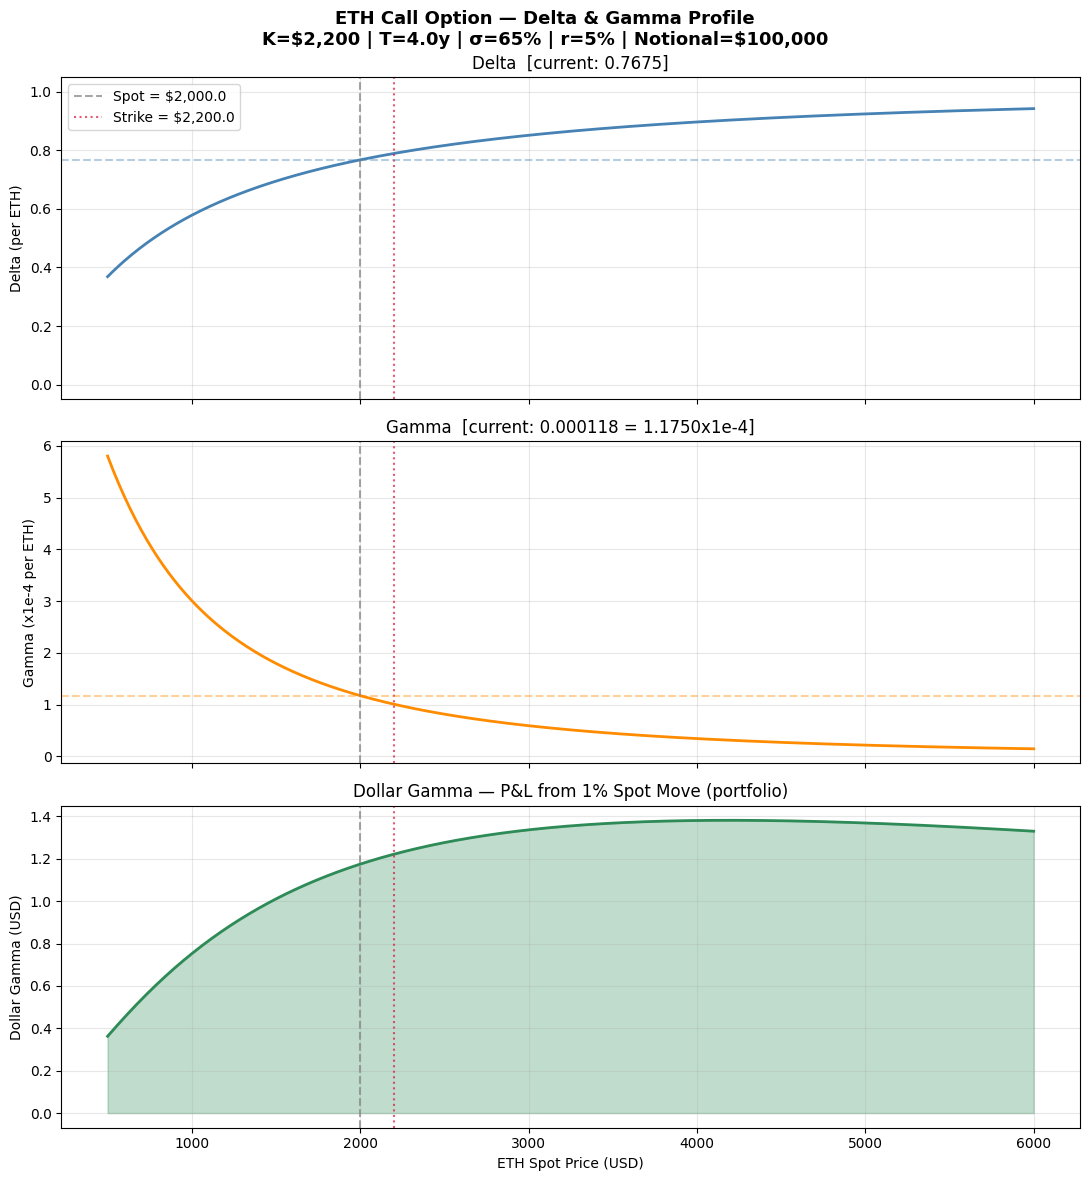

In [3]:
# ── Delta & Gamma vs Spot Price ──────────────────────────────────────────────
spots = np.linspace(500, 6000, 500)

deltas = bs_delta_call(spots, K, T, r, sigma)
gammas = bs_gamma(spots, K, T, r, sigma)

# Scale to portfolio
port_delta = deltas * qty_eth
port_gamma = gammas * qty_eth
dollar_gamma = 0.5 * gammas * spots**2 * 0.01**2 * qty_eth  # P&L per 1% spot move

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
fig.suptitle(f'ETH Call Option — Delta & Gamma Profile\n'
             f'K=\${K:,.0f} | T={T}y | \u03c3={sigma:.0%} | r={r:.0%} | Notional=\${notional_usd:,.0f}',
             fontsize=13, fontweight='bold')

# Delta
axes[0].plot(spots, deltas, color='steelblue', lw=2)
axes[0].axvline(S0, color='gray', ls='--', alpha=0.7, label=f'Spot = \${S0:,}')
axes[0].axvline(K,  color='crimson', ls=':', alpha=0.7, label=f'Strike = \${K:,}')
axes[0].axhline(delta_now, color='steelblue', ls='--', alpha=0.4)
axes[0].set_ylabel('Delta (per ETH)')
axes[0].set_title(f'Delta  [current: {delta_now:.4f}]')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Gamma
axes[1].plot(spots, gammas * 1e4, color='darkorange', lw=2)
axes[1].axvline(S0, color='gray', ls='--', alpha=0.7)
axes[1].axvline(K,  color='crimson', ls=':', alpha=0.7)
axes[1].axhline(gamma_now * 1e4, color='darkorange', ls='--', alpha=0.4)
axes[1].set_ylabel('Gamma (x1e-4 per ETH)')
axes[1].set_title(f'Gamma  [current: {gamma_now:.6f} = {gamma_now*1e4:.4f}x1e-4]')
axes[1].grid(alpha=0.3)

# Dollar Gamma (P&L per 1% move, full portfolio)
axes[2].fill_between(spots, dollar_gamma, alpha=0.3, color='seagreen')
axes[2].plot(spots, dollar_gamma, color='seagreen', lw=2)
axes[2].axvline(S0, color='gray', ls='--', alpha=0.7)
axes[2].axvline(K,  color='crimson', ls=':', alpha=0.7)
axes[2].set_ylabel('Dollar Gamma (USD)')
axes[2].set_xlabel('ETH Spot Price (USD)')
axes[2].set_title('Dollar Gamma — P&L from 1% Spot Move (portfolio)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_spot.png', dpi=150, bbox_inches='tight')
plt.show()


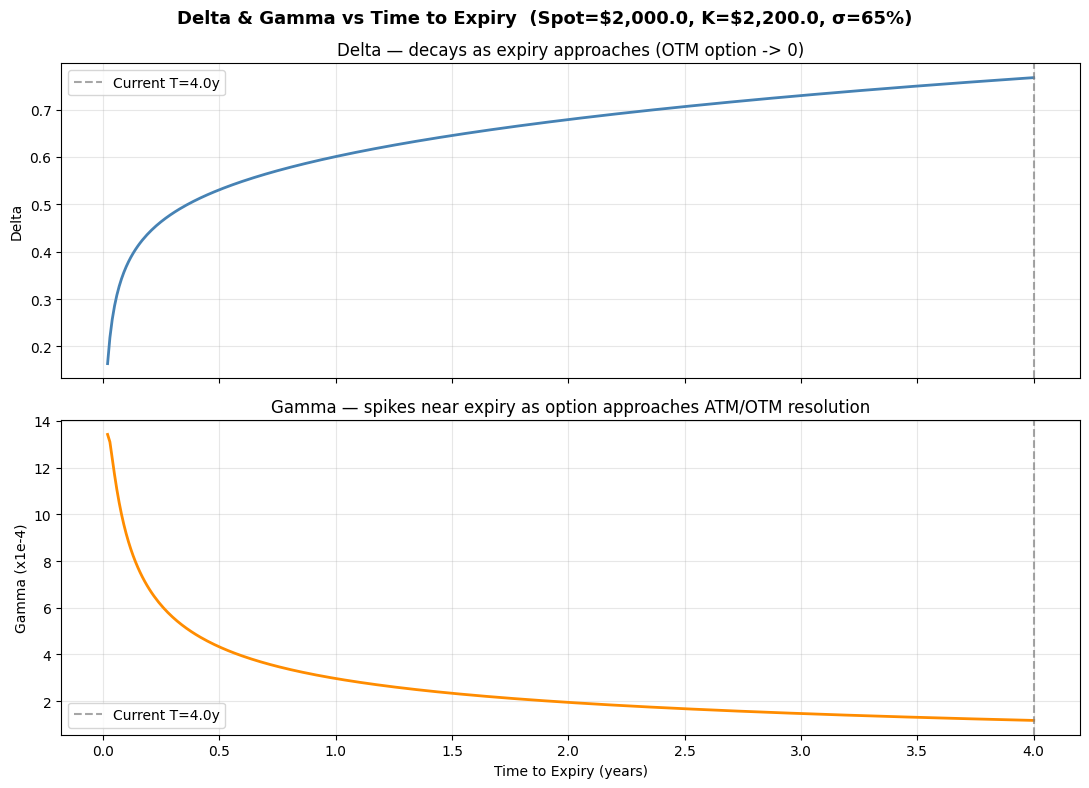

In [4]:
# ── Delta & Gamma vs Time to Expiry (at current spot) ───────────────────────
times = np.linspace(0.02, 4.0, 400)   # avoid T=0 singularity

deltas_t = bs_delta_call(S0, K, times, r, sigma)
gammas_t = bs_gamma(S0, K, times, r, sigma)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle(f'Delta & Gamma vs Time to Expiry  (Spot=\${S0:,}, K=\${K:,}, \u03c3={sigma:.0%})',
             fontsize=13, fontweight='bold')

ax1.plot(times, deltas_t, color='steelblue', lw=2)
ax1.axvline(T, color='gray', ls='--', alpha=0.7, label=f'Current T={T}y')
ax1.set_ylabel('Delta')
ax1.set_title('Delta — decays as expiry approaches (OTM option -> 0)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(times, gammas_t * 1e4, color='darkorange', lw=2)
ax2.axvline(T, color='gray', ls='--', alpha=0.7, label=f'Current T={T}y')
ax2.set_ylabel('Gamma (x1e-4)')
ax2.set_xlabel('Time to Expiry (years)')
ax2.set_title('Gamma — spikes near expiry as option approaches ATM/OTM resolution')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_time.png', dpi=150, bbox_inches='tight')
plt.show()


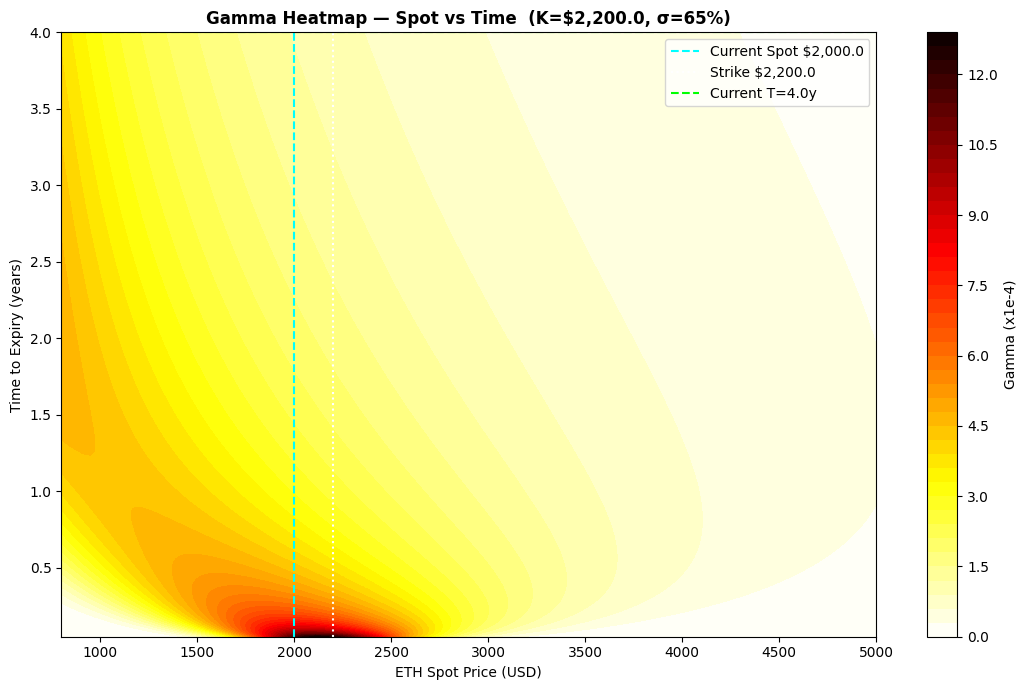

In [5]:
# ── Gamma Heatmap: Spot × Time ───────────────────────────────────────────────
spots_2d = np.linspace(800, 5000, 200)
times_2d = np.linspace(0.05, 4.0, 200)
SS, TT = np.meshgrid(spots_2d, times_2d)

GG = bs_gamma(SS, K, TT, r, sigma) * 1e4

fig, ax = plt.subplots(figsize=(11, 7))
cf = ax.contourf(SS, TT, GG, levels=50, cmap='hot_r')
fig.colorbar(cf, ax=ax, label='Gamma (x1e-4)')
ax.set_xlabel('ETH Spot Price (USD)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_title(f'Gamma Heatmap — Spot vs Time  (K=\${K:,}, \u03c3={sigma:.0%})', fontweight='bold')
ax.axvline(S0, color='cyan', lw=1.5, ls='--', label=f'Current Spot \${S0:,}')
ax.axvline(K,  color='white', lw=1.5, ls=':', label=f'Strike \${K:,}')
ax.axhline(T,  color='lime', lw=1.5, ls='--', label=f'Current T={T}y')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('gamma_scalp_v2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ── Summary Table ────────────────────────────────────────────────────────────
print("=" * 60)
print("POSITION SUMMARY")
print("=" * 60)
scenario_spots = [1000, 1500, 2000, 2200, 2500, 3000, 4000]
print(f"{'Spot':>8} {'Delta':>8} {'Gamma(e-4)':>12} {'DollarGamma':>14} {'OptPrice':>10}")
print("-" * 60)
for s in scenario_spots:
    d  = bs_delta_call(s, K, T, r, sigma)
    g  = bs_gamma(s, K, T, r, sigma)
    dg = 0.5 * g * s**2 * 0.01**2 * qty_eth
    p  = bs_price_call(s, K, T, r, sigma)
    marker = " ◄ current" if s == S0 else ""
    print(f"${s:>7,} {d:>8.4f} {g*1e4:>12.4f} ${dg:>13,.2f} ${p:>9,.2f}{marker}")

POSITION SUMMARY
    Spot    Delta   Gamma(e-4)    DollarGamma   OptPrice
------------------------------------------------------------
$  1,000   0.5782       3.0096 $         0.75 $   334.90
$  1,500   0.6947       1.7971 $         1.01 $   655.63
$  2,000   0.7675       1.1750 $         1.18 $ 1,022.46 ◄ current
$  2,200   0.7893       1.0098 $         1.22 $ 1,178.18
$  2,500   0.8165       0.8171 $         1.28 $ 1,419.19
$  3,000   0.8514       0.5941 $         1.34 $ 1,836.64
$  4,000   0.8968       0.3452 $         1.38 $ 2,712.80
